In [31]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv("../data/processed/water_potability_cleaned.csv")

In [33]:
df.shape

(3276, 10)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   hardness         3276 non-null   float64
 2   solids           3276 non-null   float64
 3   chloramines      3276 non-null   float64
 4   sulfate          2495 non-null   float64
 5   conductivity     3276 non-null   float64
 6   organic_carbon   3276 non-null   float64
 7   trihalomethanes  3114 non-null   float64
 8   turbidity        3276 non-null   float64
 9   potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [35]:
df.describe()

,ph,hardness,solids,chloramines,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [36]:
df["potability"].value_counts()

potability
0    1998
1    1278
Name: count, dtype: int64

In [37]:
df["potability"].value_counts(normalize=True) * 100

potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64

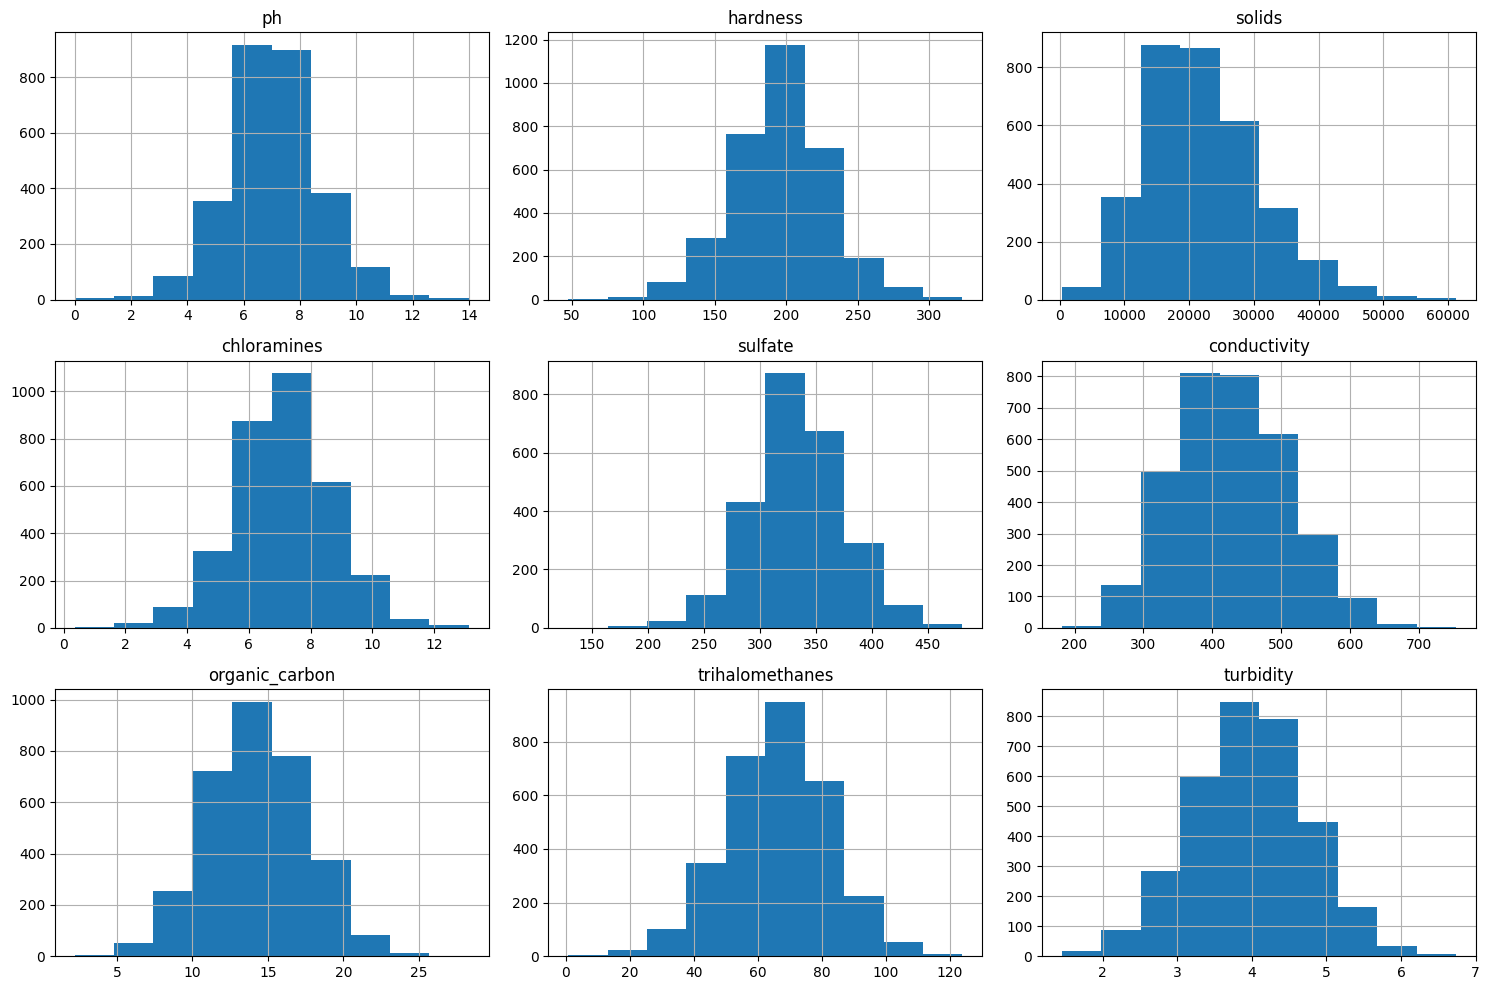

In [38]:
df.drop(columns="potability").hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

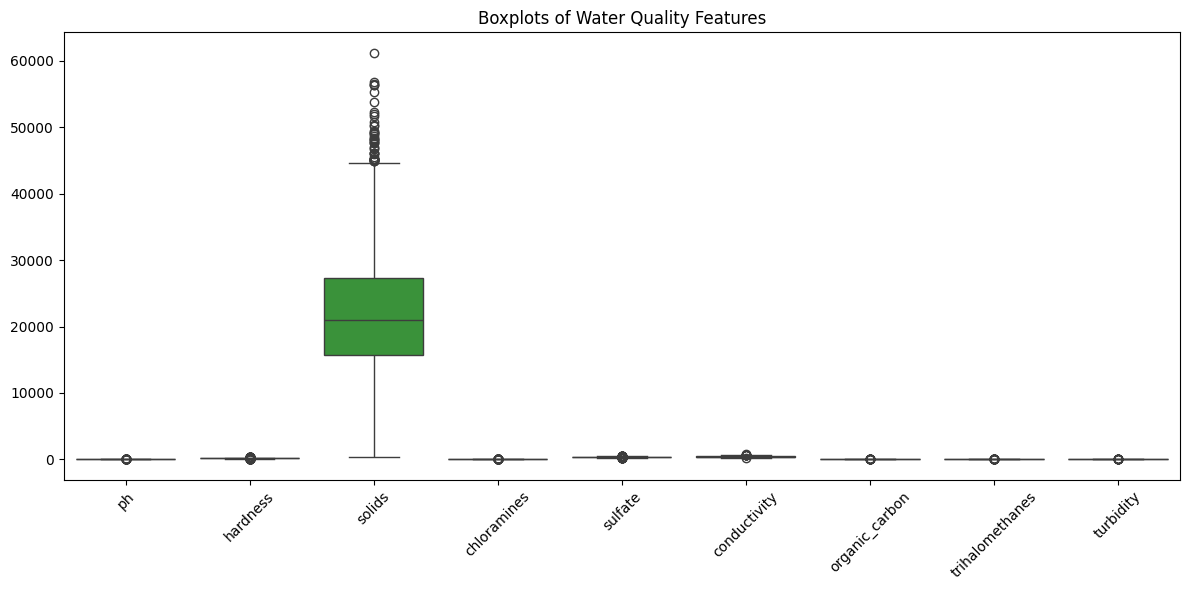

In [39]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df.drop(columns='potability'))

plt.xticks(rotation=45)
plt.title("Boxplots of Water Quality Features")
plt.tight_layout()
plt.show()

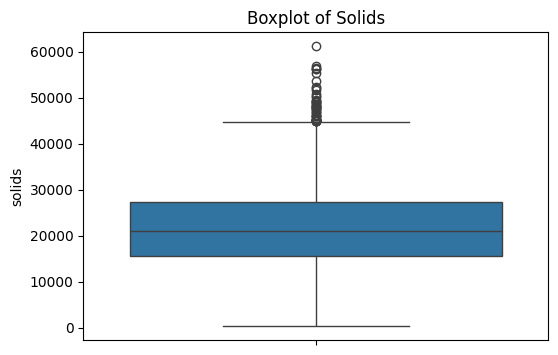

In [40]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['solids'])
plt.title('Boxplot of Solids')
plt.show()

In [41]:
df[df['solids'] > 60000]

,ph,hardness,solids,chloramines,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
2602,NaN,159.399398,61227.196008,3.713594,312.976254,377.067972,17.246698,82.197233,3.860807,0


In [42]:
df['solids'].describe()

count     3276.000000
mean     22014.092526
std       8768.570828
min        320.942611
25%      15666.690297
50%      20927.833607
75%      27332.762127
max      61227.196008
Name: solids, dtype: float64

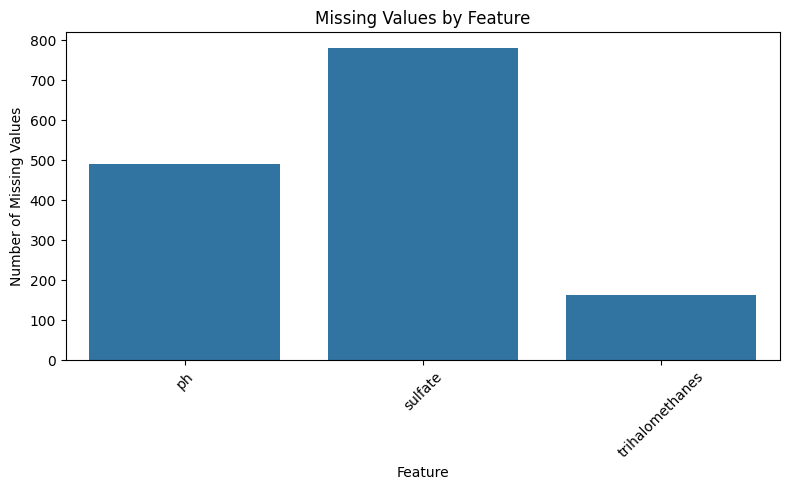

In [43]:
missing = df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(8, 5))
sns.barplot(x=missing.index, y=missing.values)

plt.title("Missing Values by Feature")
plt.ylabel("Number of Missing Values")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

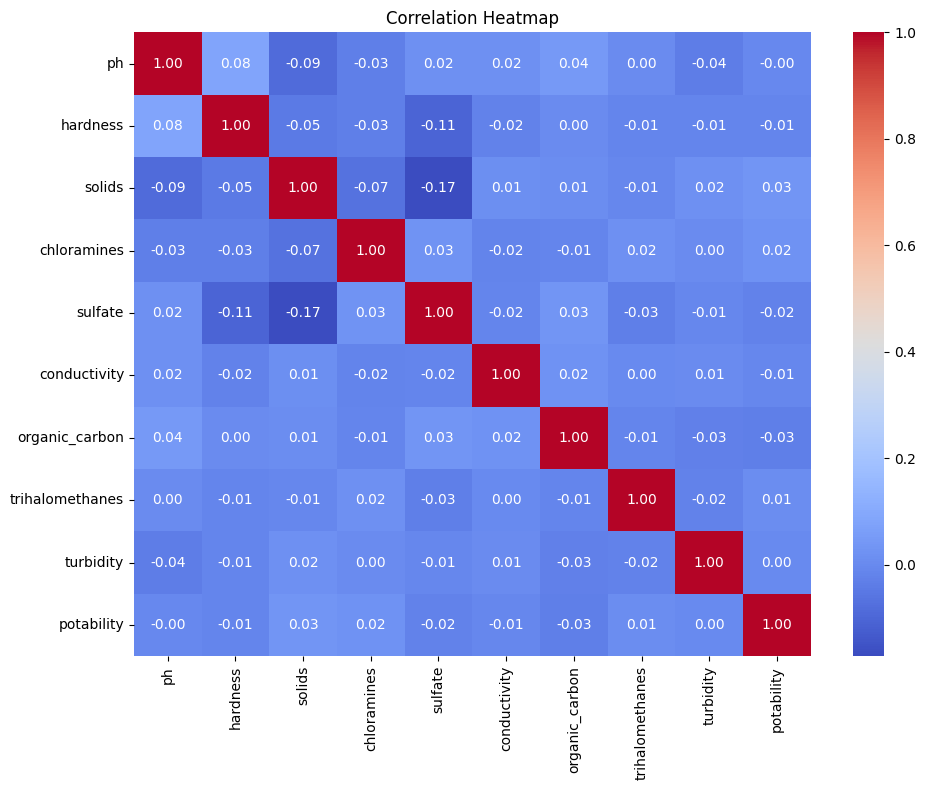

In [44]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

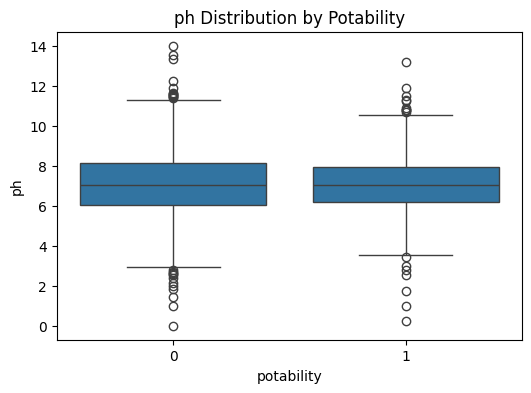

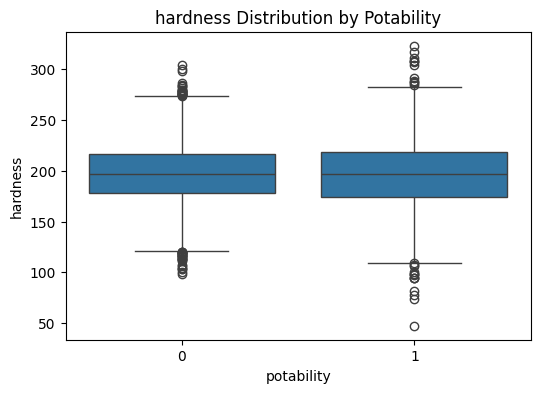

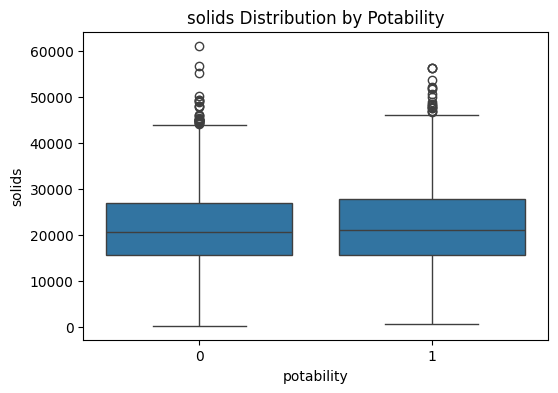

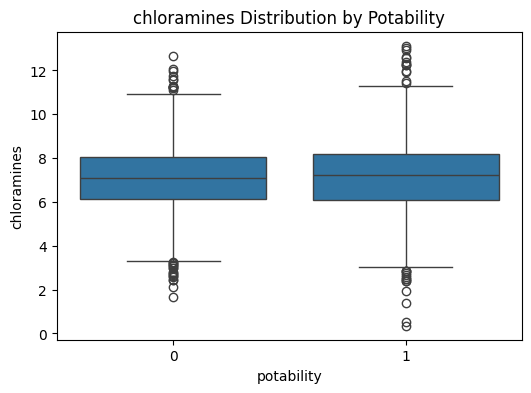

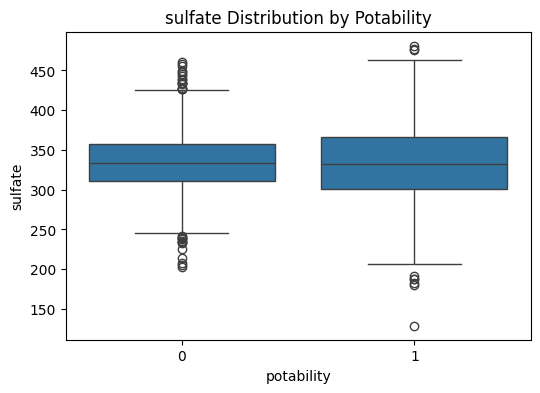

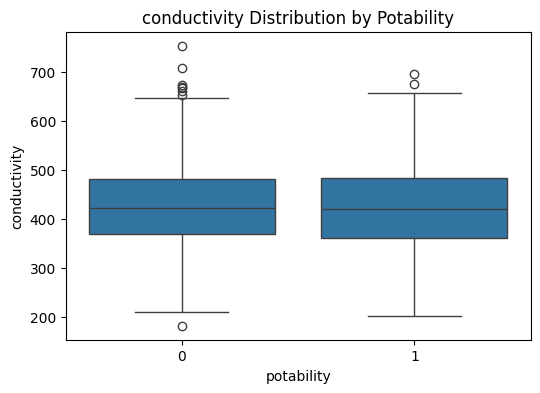

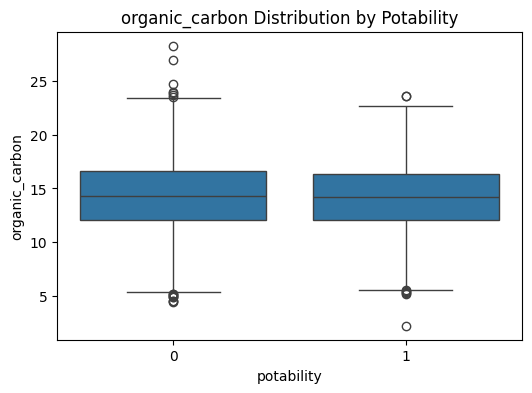

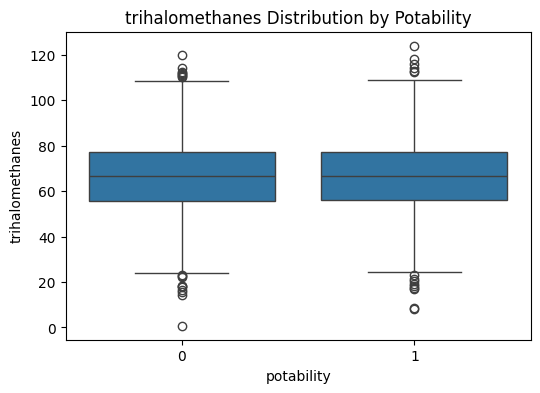

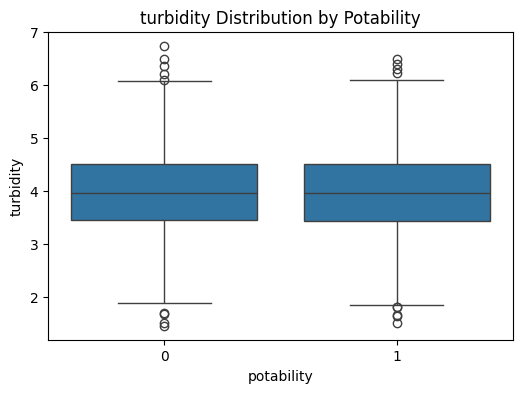

In [45]:
features = df.drop(columns='potability').columns

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='potability', y=feature, data=df)
    plt.title(f'{feature} Distribution by Potability')
    plt.show()

In [46]:
df.to_csv("../data/processed/water_potability_cleaned.csv", index=False)